In [8]:
######################
# Load the fUSI data #
######################

import nibabel as nib
import numpy as np
from pathlib import Path
import tqdm
import matplotlib.pyplot as plt
import os

# Define the base path where your NIfTI files are stored
base_path = Path('/Users/clairenastaskin/data/2025-06-03/sub-Forest001_ses-20250603_task-movements_run-001')  
pwd_file_name = 'sub-Forest001_ses-20250603_task-movements_run-001_pwd_db.nii.gz'

pwd_path = base_path / pwd_file_name
# Load fUSI nifti file and get data into a numpy array
nifti_img = nib.load(pwd_path)
fusi_data = nifti_img.get_fdata()
fusi_data = np.nan_to_num(fusi_data, nan=0) # no nan
print(fusi_data.shape)

(154, 74, 60, 823)


In [2]:
# # Extract affine transformation matrix from the NIfTI image
# affine = nifti_img.affine
# print("Affine transformation matrix:")
# print(affine)
# print(affine.shape)

# # Update the affine
# affine[2,3] = -19.35891719 + 4.2
# print(affine)

# # Create new NIfTI image with updated affine
# new_img = nib.Nifti1Image(fusi_data, affine)

# # Save the new NIfTI file
# output_path = base_path / 'pwd_updated_affine.nii.gz'
# nib.save(new_img, output_path)

Affine transformation matrix:
[[  0.51333332   0.           0.         -45.17333221]
 [  0.          -0.51333332   0.          21.81666756]
 [  0.           0.          -0.51333332 -23.558918  ]
 [  0.           0.           0.           1.        ]]
(4, 4)


Sequence type:  n/a
frame_times:  [   2.001499    3.801739    5.601723    7.401838    9.201871   11.002269
   12.802281   14.602459   16.402779   18.20282    20.002933   21.802909
   23.603445   25.403368   27.203595   29.003624   30.803729   32.604093
   34.403832   36.204018   38.004248   39.804954   41.605266   43.40479
   45.205084   47.004964   48.805087   50.605162   52.405654   54.205513
   56.00588    57.806013   59.605971   61.406315   63.206143   65.006296
   66.806593   68.606772   70.407126   72.206863   74.007359   75.807459
   77.607655   79.407725   81.207823   83.00807    84.807954   86.608225
   88.408427   90.208518   92.009018   93.809002   95.609048   97.408993
   99.209156  101.009438  102.809702  104.609618  106.409747  108.209885
  110.010179  111.810236  113.610267  115.41057   117.210577  119.010938
  120.810781  122.610951  124.411051  126.211473  128.011464  129.811867
  131.611911  133.412051  135.212073  137.012419  138.812241  140.612587
  142.412805  144.

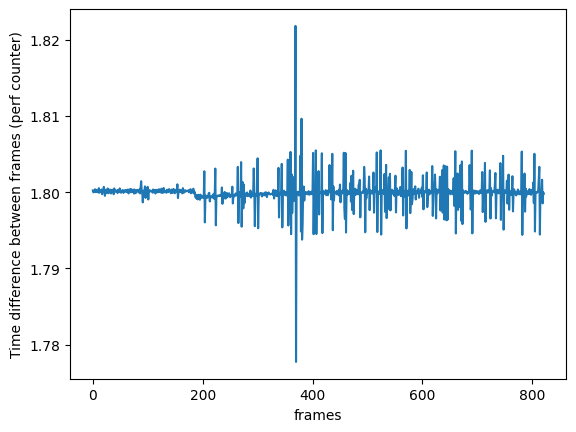

In [2]:
#############################
# Import Forest1 json info #
############################
import json
from glob import glob
import numpy as np
import os

Forest1_info_file = base_path / "*pwd.json"
# Get the json file path using glob
info_file_path = glob(str(Forest1_info_file))[0]

# Read the json file
with open(info_file_path, 'r') as f:
    info = json.load(f)

# Set dimensions based on sequence name
if info['SequenceName'] == "deep":
    dim_volume = [0, 60, 92, 25]
elif info['SequenceName'] == "shallow":
    dim_volume = [0, 60, 42, 25]
print( 'Sequence type: ', info['SequenceName'])

frame_times = info['VolumeTiming']
frame_times = np.array(frame_times)
print('frame_times: ', frame_times)

diff_perf = np.diff(frame_times)
fig, ax = plt.subplots()
ax.plot(diff_perf)
ax.set_ylabel('Time difference between frames (perf counter)')
ax.set_xlabel('frames')
t_r = np.median(diff_perf)
t_r

# Save t_r value to base_path
np.save(os.path.join(base_path, 't_r.npy'), t_r)


In [9]:
#######################################################################################
#     Display and save power Doppler movie, and display overall intensity over time   #
#######################################################################################
dim_volume = [0, 60, 42, 25]

from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import matplotlib.pyplot as plt

movie_path = base_path / "Doppler_movie.mp4"

if not movie_path.exists():
    # Convert to dB scale
    fusi_data_dB = 10*np.log10(fusi_data)
    nnz_idx = fusi_data > np.finfo(fusi_data.dtype).eps
    vmax = np.percentile(fusi_data_dB[nnz_idx], 90)
    vmin = np.percentile(fusi_data_dB[nnz_idx], 10)
    print(vmin)
    print('dynamic range: ', vmax-vmin)
    
    # Save fusi_data_dB as a NIfTI file
    output_filename = pwd_file_name.replace('.nii.gz', '_db.nii.gz')
    output_path = base_path / output_filename
    nifti_img_db = nib.Nifti1Image(fusi_data_dB, nifti_img.affine, nifti_img.header)
    nib.save(nifti_img_db, output_path)

    # Create animation
    fig, ax = plt.subplots()
    cax = ax.imshow(fusi_data_dB[:, fusi_data_dB.shape[1]//2, :, 0].T, cmap="inferno", extent=dim_volume, vmax=vmax+7, vmin=vmin)
    plt.colorbar(cax, ax=ax, label='Intensity (dB)')
    ax.set_title("0")

    ax.set_xlabel("Y (mm)")
    ax.set_ylabel("X (mm)")

    def update(frame):
        cax.set_data(fusi_data_dB[:, fusi_data_dB.shape[1]//2,:, frame].T)
        ax.set_title(f"Frame # {frame}")

    frames_to_plot = range(0, fusi_data_dB.shape[3], 1)
    ani = FuncAnimation(fig, update, frames=frames_to_plot, interval=100)

    # Save the animation
    ani.save(movie_path, writer="ffmpeg")
    plt.close(fig)

# Display the saved movie
from IPython.display import Video
from IPython.display import display
display(Video(str(movie_path), embed=True, width=800, html_attributes="controls autoplay"))


global_signal = np.mean(fusi_data, axis=(0, 1, 2))
fig,ax = plt.subplots()
ax.plot(global_signal)
ax.set_title("Global signal")
ax.set_xlabel("Frame #")
ax.set_ylabel("Average Intensity")
fig.savefig(base_path / "global_signal.png")

/var/folders/50/vlgy95sd2d1d6w1_l8pgqd1c0000gn/T/ipykernel_4041/2317016339.py:14: RuntimeWarning: invalid value encountered in log10
  fusi_data_dB = 10*np.log10(fusi_data)


16.59695545517495
dynamic range:  0.30120883889021854


KeyboardInterrupt: 

/Users/clairenastaskin/Documents/Anise/.venv/lib/python3.9/site-packages/numpy/lib/function_base.py:1452: RuntimeWarning: invalid value encountered in subtract
  a = op(a[slice1], a[slice2])


Text(0, 0.5, 'Derivative of global signal')

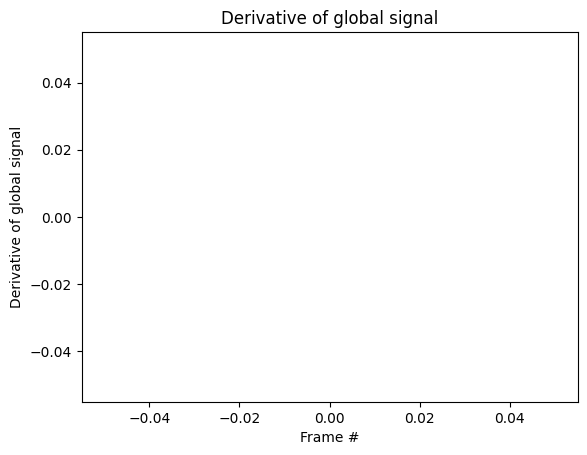

In [4]:
deriv_global_signal = np.diff(global_signal)
fig,ax = plt.subplots()
ax.plot(deriv_global_signal)
ax.set_title("Derivative of global signal")
ax.set_xlabel("Frame #")
ax.set_ylabel("Derivative of global signal")



In [15]:
# ##############################################
# # Extract Psychotria time_stamps #
# ##############################################
import pandas as pd

task_path = list(base_path.glob('*events.tsv'))[0]
task_events = pd.read_csv(task_path, sep='\t')

task_events

,trial_type,onset,duration
0,Right foot,14.69,11.0
1,Left fingers,37.69,12.0
2,Right fingers,61.69,11.0
3,Lip Sync,83.69,13.0
4,Right foot,106.69,12.0
5,Right fingers,161.69,10.0
6,Right foot,186.69,12.0
7,Right wrist,212.69,11.0
8,Left fingers,234.69,14.0
9,Left foot,262.69,11.0


Indexes to mask =  []
(823,)


/Users/clairenastaskin/Documents/Anise/.venv/lib/python3.9/site-packages/numpy/core/_methods.py:118: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/Users/clairenastaskin/Documents/Anise/.venv/lib/python3.9/site-packages/nilearn/signal.py:270: RuntimeWarning: invalid value encountered in subtract
  signals -= np.mean(signals, axis=0)
/var/folders/50/vlgy95sd2d1d6w1_l8pgqd1c0000gn/T/ipykernel_4041/3803288311.py:22: DeprecationWarning: The default strategy for standardize is currently 'zscore' which incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.13, the default strategy will be replaced by the new strategy and the 'zscore' option will be removed. Please use 'zscore_sample' instead.
  average_over_time_detrended = clean(
/Users/clairenastaskin/Documents/Anise/.venv/lib/python3.9/site-packages/numpy/core/_methods.py:206: R

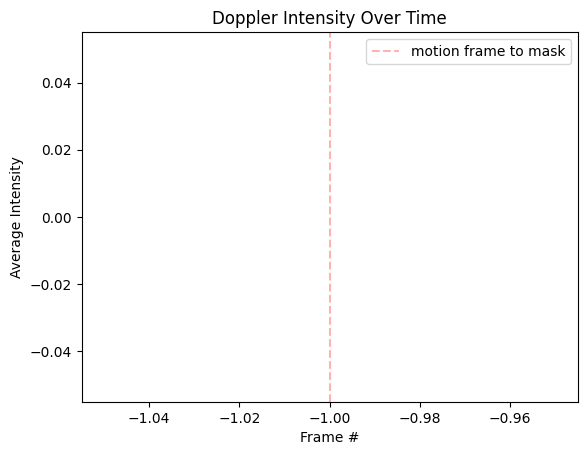

In [5]:
##########################################################################################
#     Display Doppler intensity time course and create a sample_masks for motion frames  #
##########################################################################################

from nilearn.signal import clean

fusi_data = fusi_data[:, :, :, :]
average_over_time = np.mean(fusi_data, axis=(0, 1, 2))
fig,ax = plt.subplots()
ax.plot(average_over_time)
ax.set_title("Doppler Intensity Over Time")
ax.set_xlabel("Frame #")
ax.set_ylabel("Average Intensity")


###################################################
# Detrend the time course to remove linear trends #
###################################################

# Reshape to 2D array since clean expects samples x features
average_over_time_2d = average_over_time.reshape(-1, 1)
average_over_time_detrended = clean(
    average_over_time_2d,
    detrend=True,
    t_r=t_r,
)
# Convert back to 1D array
average_over_time_detrended = average_over_time_detrended.ravel()

#######################################################################################################################
# Based on detrended signal, find motion frames (here defined as frames with values higher than median + 5 times std) #
#######################################################################################################################
median_detrended_signal=np.median(average_over_time_detrended)
perc_50 = np.percentile(average_over_time_detrended,50)
perc_50_signal = average_over_time_detrended[average_over_time_detrended < perc_50]
std_perc_50 = np.std(perc_50_signal)

# Find frames with values > median + 5*std of lower 50% of signal
index_to_mask = np.where(average_over_time_detrended > (median_detrended_signal + 30*std_perc_50))[0]
# Add vertical lines for motion frames
for frame in index_to_mask:
    ax.axvline(x=frame, color='r', linestyle='--', alpha=0.3)
ax.axvline(x=-1, color='r', linestyle='--', alpha=0.3, label='motion frame to mask')
ax.legend()
print('Indexes to mask = ', index_to_mask)

#############################
#     Create sample_masks  #
############################
sample_masks = np.zeros(fusi_data.shape[3] - len(index_to_mask), dtype=int)
t = 0
for i in range(fusi_data.shape[3]):
    if i not in index_to_mask:
        sample_masks[t] = i
        t += 1

print(sample_masks.shape)

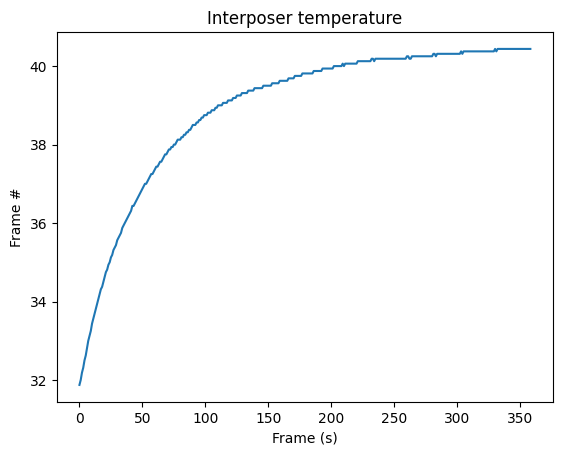

In [8]:
# # ################################
# # # Plot temperature time course #    
# # ################################

temp_log= info['ProbeTemperature'] 


fig,ax = plt.subplots()
ax.plot(temp_log)
ax.set_title('Interposer temperature')
ax.set_xlabel('Frame (s)')
ax.set_ylabel('Frame #')
plt.show()
fig.savefig(base_path / "interposer_temperature.png")

/Users/clairenastaskin/Documents/Anise/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


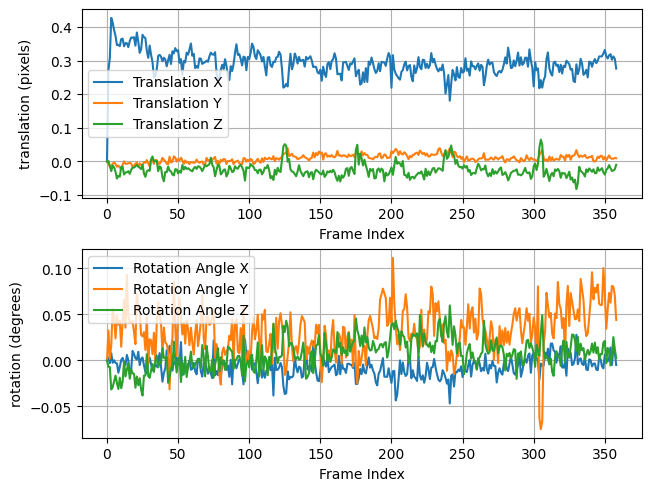

In [9]:
#########################################
#######  Rigid transformation  #########
########################################
import fusi_utils_Forest1 as utils

transformation_file = base_path / "rigid_transformations.nii.gz"

if not transformation_file.exists():
    fusi_data_rigid_reg, rigid_transformations = utils.register_3d_image_stack(fusi_data)
    
    # Save rigid transformations to file
    affine = np.diag([1, 1, 1, 1])
    nib.save(nib.Nifti1Image(rigid_transformations, affine), transformation_file)
    nib.save(nib.Nifti1Image(fusi_data_rigid_reg, affine), base_path / "fusi_data_rigid_reg.nii.gz")
else:
    # Load rigid transformations from file
    rigid_transformations = nib.load(transformation_file).get_fdata()
    fusi_data_rigid_reg = nib.load(base_path / "fusi_data_rigid_reg.nii.gz").get_fdata()

# Plot rigid_transformations
fig, axes = plt.subplots(nrows=2, ncols=1,layout="constrained")
ax_tran=axes[0]
ax_tran.plot(rigid_transformations[0, :], label="Translation X")
ax_tran.plot(rigid_transformations[1, :], label="Translation Y")
ax_tran.plot(rigid_transformations[2, :], label="Translation Z")
ax_tran.set_xlabel("Frame Index")
ax_tran.set_ylabel("translation (pixels)")
ax_tran.legend()
ax_tran.grid(True)
ax_tran.legend()

ax_rot=axes[1]
ax_rot.plot(rigid_transformations[3, :] * 180 / np.pi, label="Rotation Angle X")
ax_rot.plot(rigid_transformations[4, :] * 180 / np.pi, label="Rotation Angle Y")
ax_rot.plot(rigid_transformations[5, :] * 180 / np.pi, label="Rotation Angle Z")
ax_rot.set_xlabel("Frame Index")
ax_rot.set_ylabel("rotation (degrees)")
ax_rot.legend()
ax_rot.grid(True)
ax_rot.legend()

# Save figure
fig.savefig(base_path / "registration.png")
# plt.close()


In [10]:
######################################################################
#     Display and save power Doppler movie after rigid registration  #
######################################################################

movie_file = base_path / "Doppler_movie_after_rigid_registration.mp4"

if not movie_file.exists():
    fusi_data_rigid_reg_dB = 10*np.log10(fusi_data_rigid_reg)
    nnz_idx = fusi_data_rigid_reg > np.finfo(fusi_data_rigid_reg.dtype).eps
    vmax = np.percentile(fusi_data_rigid_reg_dB[nnz_idx], 90)
    vmin = np.percentile(fusi_data_rigid_reg_dB[nnz_idx], 10)
    print(vmin)
    print('dynamic range: ', vmax-vmin)

    # Create figure and initial plot
    fig, ax = plt.subplots()
    cax = ax.imshow(
        fusi_data_rigid_reg_dB[:, int(fusi_data_rigid_reg_dB.shape[1] / 2), :, 0].T,
        cmap="inferno",
        vmax=vmax+7, vmin=vmin,
        extent=dim_volume,
    )
    ax.set_title("0")

    # Set axis labels
    ax.set_xlabel("Y (mm)")
    ax.set_ylabel("X (mm)")
    plt.colorbar(cax, ax=ax, label='Intensity (dB)')

    def update(frame):
        cax.set_data(
            fusi_data_rigid_reg_dB[:, int(fusi_data_rigid_reg_dB.shape[1] / 2), :, frame].T
        )
        ax.set_title(f"Frame # {frame}")
        return (cax,)

    # Create a list of frames to plot every other frame
    frames_to_plot = range(0, fusi_data_rigid_reg.shape[3], 2)
    ani = FuncAnimation(fig, update, frames=frames_to_plot, interval=100, blit=True)

    # Save the animation as an MP4 file
    ani.save(movie_file, writer="ffmpeg")
    plt.close()
    display(HTML(ani.to_jshtml()))

else:
    # Display the saved movie
    from IPython.display import Video
    from IPython.display import display
    display(Video(str(movie_file), embed=True, width=800, html_attributes="controls autoplay"))



/var/folders/50/vlgy95sd2d1d6w1_l8pgqd1c0000gn/T/ipykernel_26249/2011080958.py:37: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


<Figure size 640x480 with 0 Axes>

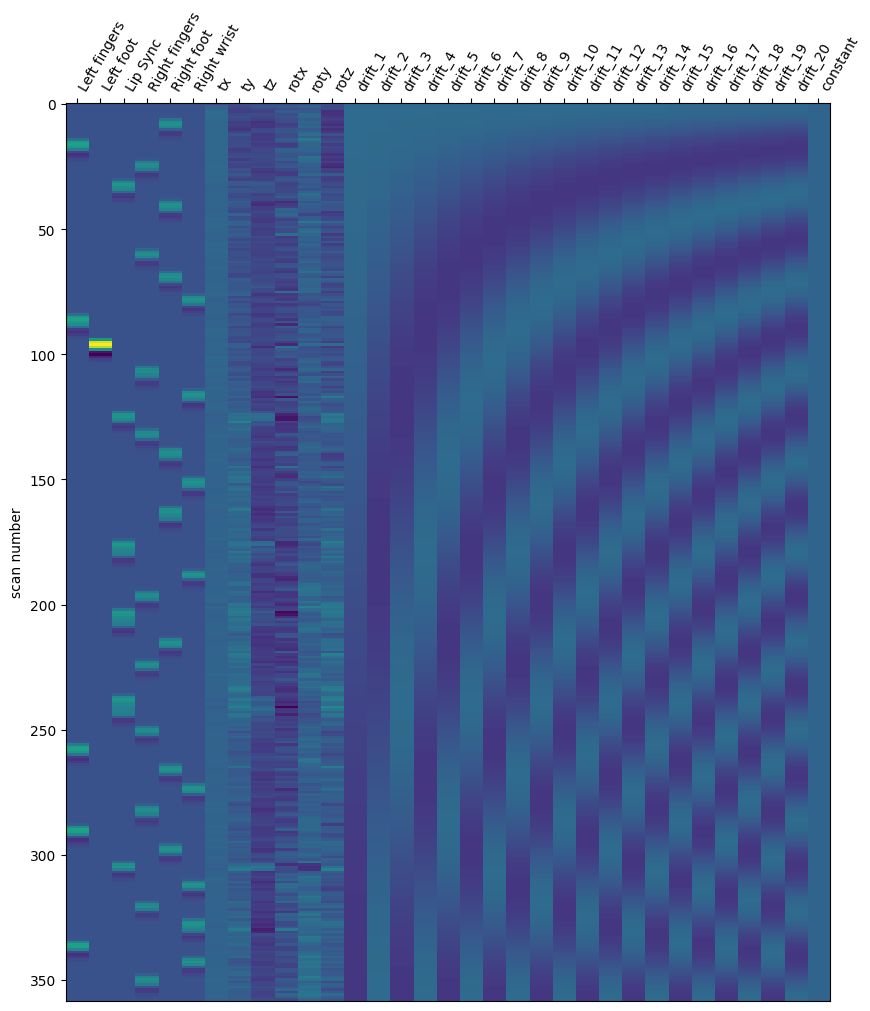

In [ ]:
#######################################
#     Create design matrix for GLM    #
#######################################
from nilearn.glm.first_level import make_first_level_design_matrix
from nilearn.plotting import plot_design_matrix
import os

# fusi_data = fusi_data_rigid_reg  # If we're happy about the registration and we want to use the registered signal
regressed_with_transformations = True # If we want to use the transformations as regressors

event_time_offset = 0  #t_r # in seconds 
task_events["onset"] += event_time_offset

if regressed_with_transformations:
    events_df = make_first_level_design_matrix(
        frame_times,
        task_events,
        drift_model="cosine", 
        high_pass=0.01,
        add_regs=rigid_transformations.transpose(),
        add_reg_names=["tx", "ty", "tz", "rotx", "roty", "rotz"],
        hrf_model="glover",
    )
else:
    events_df = make_first_level_design_matrix(
        frame_times,
        task_events,
        drift_model="cosine",
        high_pass=0.01,
        hrf_model="glover",
    )


design_matrix = events_df
fig = plt.figure()
plot_design_matrix(design_matrix)
fig.show()

# Save design matrix as .npz file
np.savez(os.path.join(base_path, 'design_matrix.npz'), design_matrix=design_matrix.values, column_names=design_matrix.columns)

In [17]:
###########################################
# Temporal smoothing and convert to NIfTI #
###########################################
import fusi_utils_Forest1 as utils

from nilearn.signal import butterworth
window_size = 3  # Number of time points for smoothing
pd = utils.boxcar_smooth(fusi_data, window_size)

affine = np.diag([1, -1, -1, 1])

# Create a NIfTI image object from our processed data (pd) and the affine matrix
fusi_img = nib.Nifti1Image(pd, affine)
fusi_img.to_filename(base_path / "fUSi_data_after_processing.nii.gz")
fusi_img.shape

(144, 68, 138, 359)

In [18]:
###########
# Fit GLM #
###########
import pandas as pd
from nilearn.glm.first_level import FirstLevelModel

smoothing_fwhm = (2) # 0 spatial smoothing in pixel to apply to the data before computing GLM

# Filter sample_masks to only include values up to fusi_img.shape[3]
sample_masks = sample_masks[sample_masks <= fusi_img.shape[3]-1]

confounds = pd.DataFrame({"global_signal": global_signal}) # if we want to include global signal as a confound

# Initialize and fit the GLM model with specified parameters
print("Fitting a GLM")
fusi_glm = FirstLevelModel(
    t_r=t_r,
    minimize_memory=False,
    mask_img=False,
    smoothing_fwhm=smoothing_fwhm,
    standardize=True,
)
fusi_glm = fusi_glm.fit(fusi_img, design_matrices=design_matrix, sample_masks=[sample_masks])
# design_matrix2 = fusi_glm.design_matrices_[0]
# fig = plt.figure()
# plot_design_matrix(design_matrix2)
# fig.show()

Fitting a GLM


/Users/clairenastaskin/Documents/Anise/.venv/lib/python3.9/site-packages/nilearn/glm/first_level/first_level.py:585: UserWarning: Mean values of 0 observed. The data have probably been centered.Scaling might not work as expected
  Y, _ = mean_scaling(Y, self.signal_scaling)


Contrasts:
- Left fingers
- Left foot
- Lip Sync
- Right fingers
- Right foot
- Right wrist
- tx
- ty
- tz
- rotx
- roty
- rotz
- constant
- right_minus_left_fingers


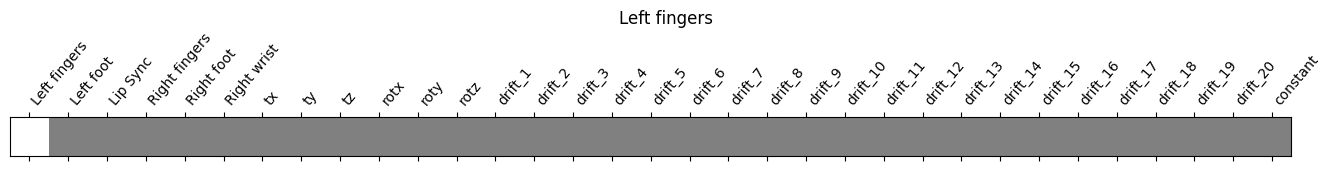

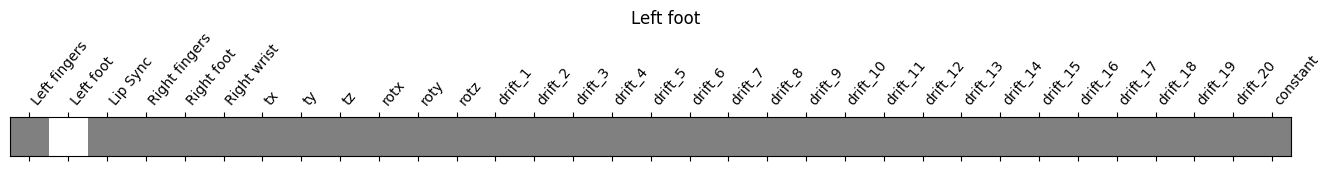

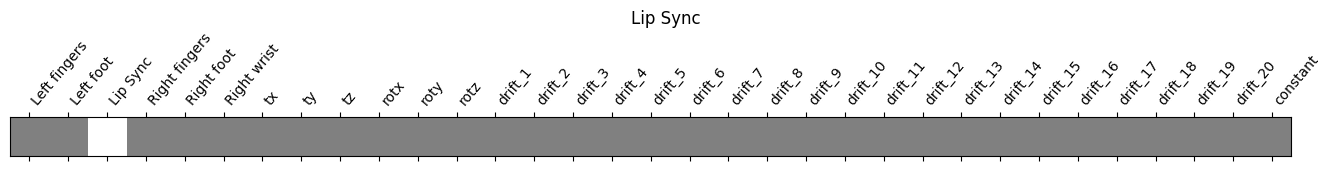

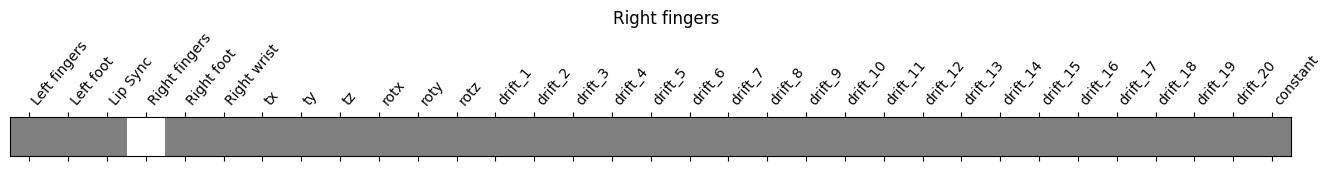

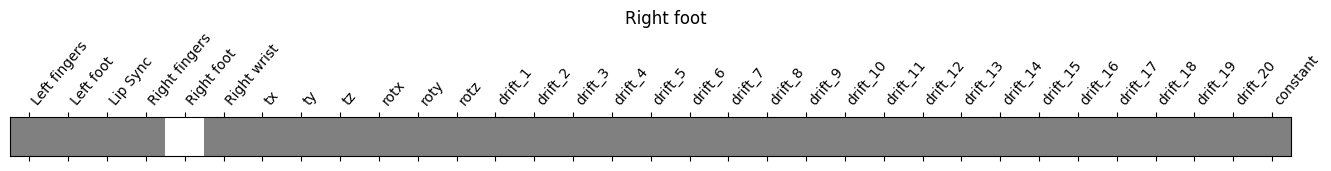

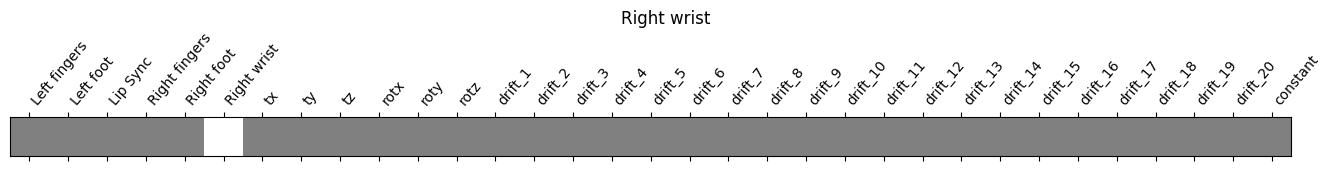

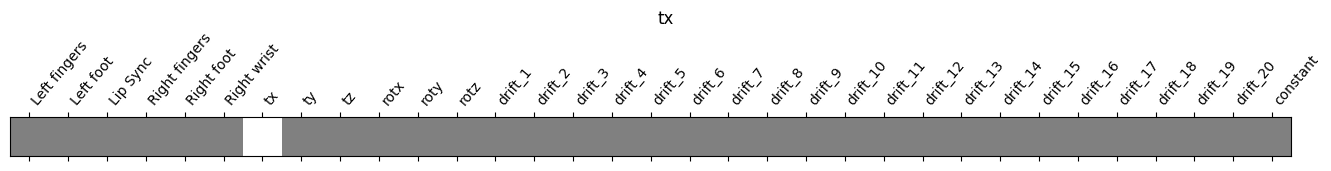

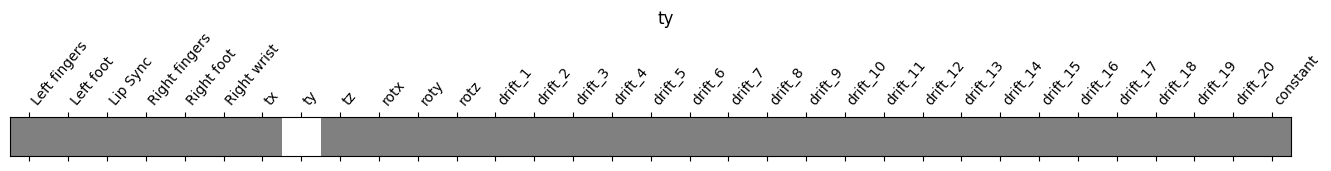

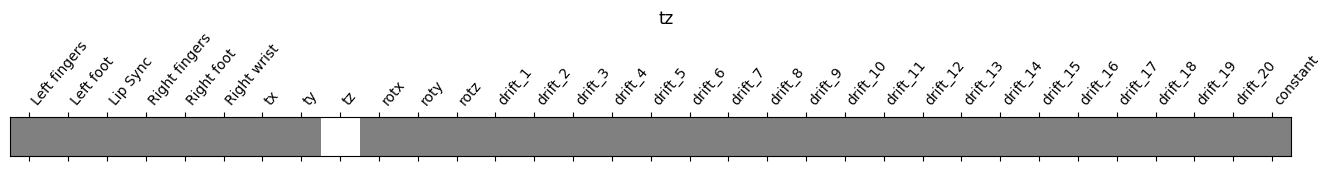

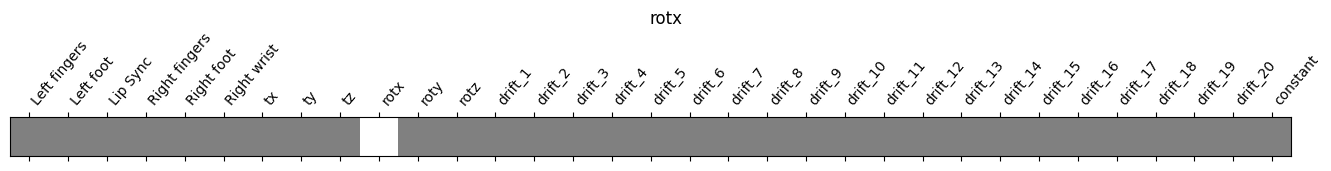

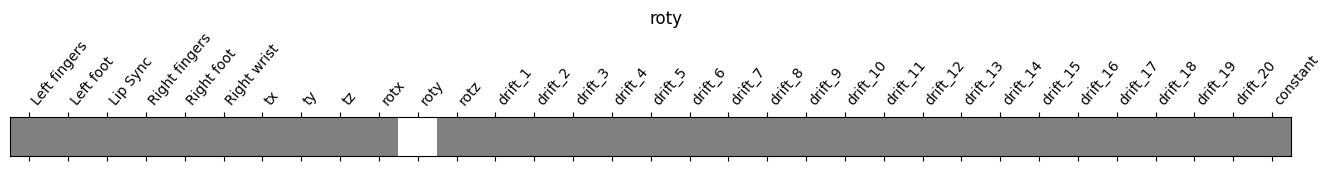

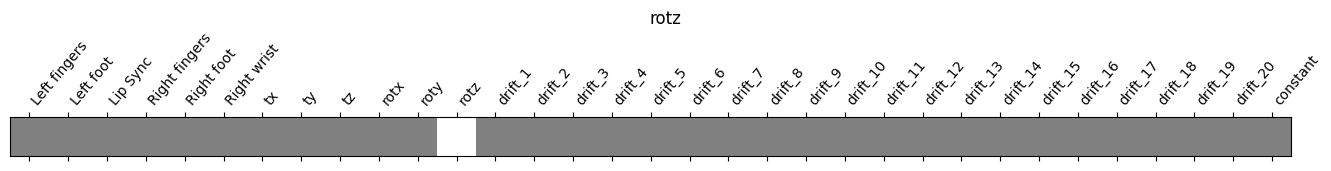

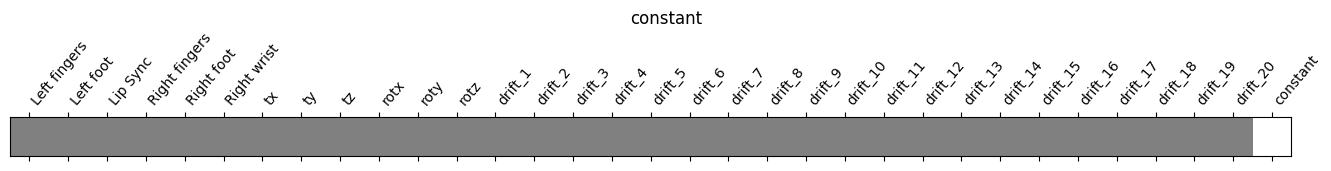

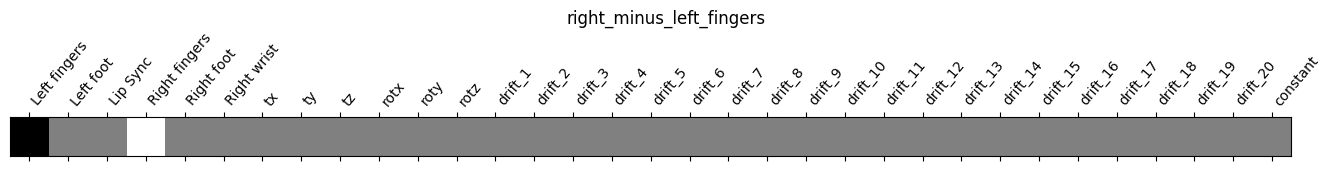

In [19]:
##########################################
## Create contrasts for localizer task ##
##########################################

from nilearn.plotting import plot_contrast_matrix


def make_localizer_contrasts(design_matrix):
    contrast_matrix = np.eye(design_matrix.shape[1])
    contrasts = {
        column: contrast_matrix[i]
        for i, column in enumerate(design_matrix.columns)
    }
    contrasts["right_minus_left_fingers"] = (
        contrasts["Right fingers"]
        - contrasts["Left fingers"])
    return contrasts
    
contrasts = make_localizer_contrasts(design_matrix)
print("Contrasts:")
for name in [k for k in contrasts.keys() if 'drift' not in k]:
    print(f"- {name}")

for key, values in contrasts.items():
    if 'drift' not in key:
        plot_contrast_matrix(values, design_matrix=design_matrix)
        plt.suptitle(key)

plt.show()

In [20]:
from nilearn import plotting


def plot_contrast(first_level_model):
    """Specify, estimate and plot the main contrasts \
        for given a first model.
    """
    design_matrix = first_level_model.design_matrices_[0]
    # Call the contrast specification within the function
    contrasts = make_localizer_contrasts(design_matrix)
    plt.figure(figsize=(20, 4))
    # compute the per-contrast z-map
    for index, (contrast_id, contrast_val) in enumerate(contrasts.items()):
        ax = plt.subplot(1, len(contrasts), 1 + index)
        z_map = first_level_model.compute_contrast(
            contrast_val, output_type="z_score"
        )
        plotting.plot_stat_map(
            z_map,
            display_mode="z",
            threshold=3.0,
            title=contrast_id,
            axes=ax,
            cut_coords=1,
        )

Computing contrasts
	contrast id: Left fingers


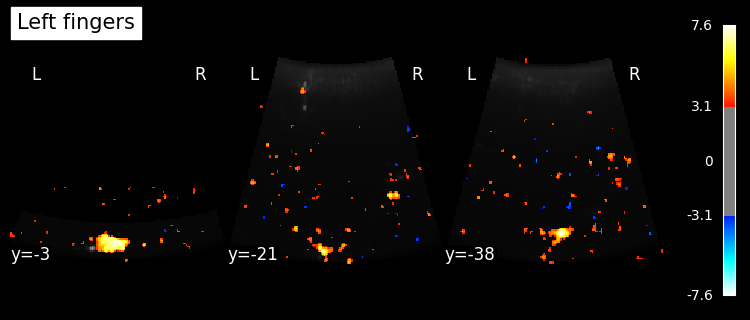

	contrast id: Left foot


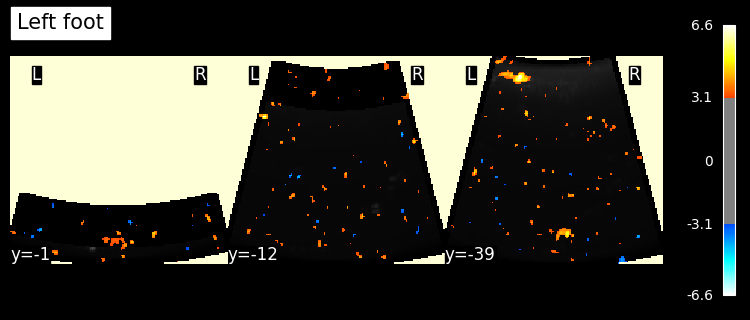

	contrast id: Lip Sync


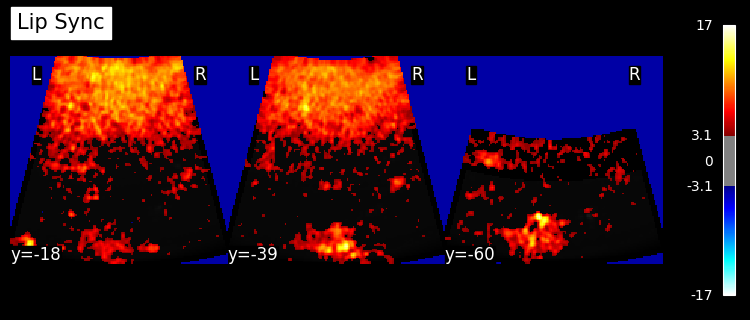

	contrast id: Right fingers


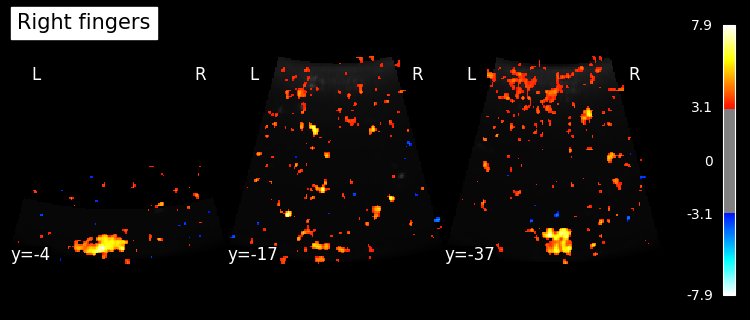

	contrast id: Right foot


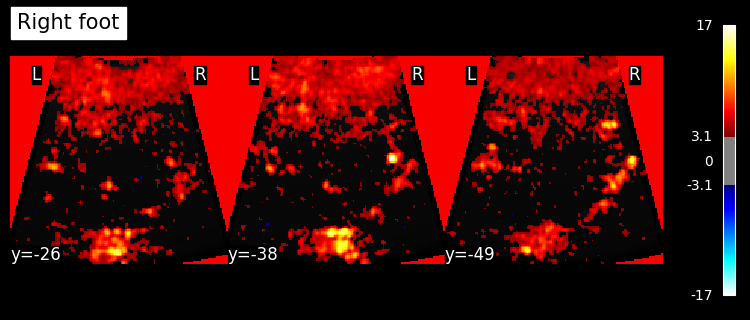

	contrast id: Right wrist


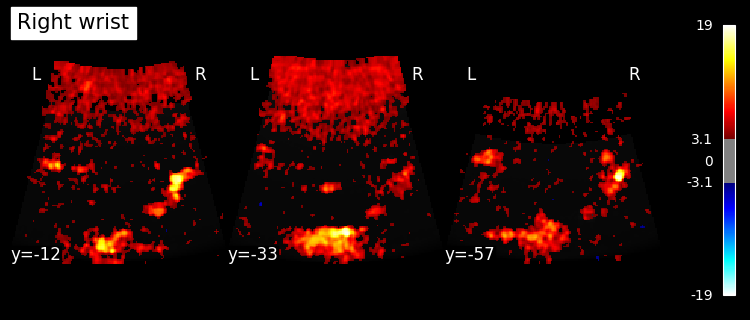

	contrast id: right_minus_left_fingers


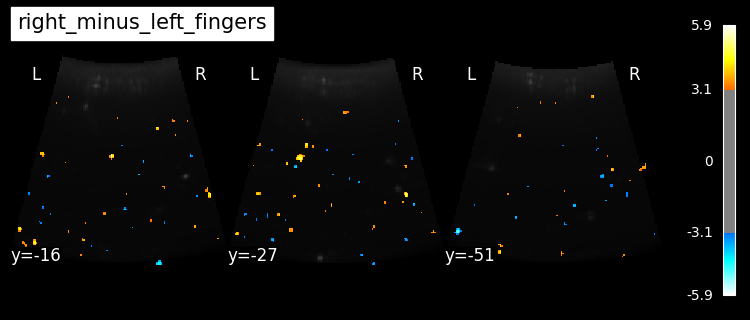

In [21]:
from nilearn import plotting
from nilearn.image import concat_imgs, mean_img, resample_img
import scipy.io
import os
import nibabel as nib
import numpy as np

print("Computing contrasts")
mean_image = nib.Nifti1Image(
    np.mean(fusi_img.get_fdata(), axis=-1), fusi_img.affine
)
os.makedirs(base_path, exist_ok=True)  # Create the directory if it doesn't exist


########################
# Iterate on contrasts #
########################

# Uncomment the line below to see all the contrasts
# for contrast_id, contrast_val in contrasts.items(): 

# Uncomment line below to see only the contrasts of the tasks and not the translations, rotations, etc ...
for contrast_id, contrast_val in {k: v for k, v in contrasts.items() if k not in ['tx', 'ty', 'tz', 'rotx', 'roty', 'rotz', 'constant'] and not k.startswith('drift')}.items():    
    print(f"\tcontrast id: {contrast_id}")
    # compute the contrasts
    z_map = fusi_glm.compute_contrast(contrast_val, output_type="stat")

    # Get the data from z_map and create new NIfTI image
    z_map_data = z_map.get_fdata()
    nii_zmap = nib.Nifti1Image(z_map_data, affine)
    # Save the NIfTI zmap to a compressed .nii.gz file in the base_path
    output_path = os.path.join(base_path, f"{contrast_id}_z_map.nii.gz")
    nib.save(nii_zmap, output_path)

    # plot the contrasts as soon as they're generated
    # the display is overlaid on the mean fusi image
    # a threshold of 2.58 is used (corresponding to p < 0.01)
    plotting.plot_stat_map(
        z_map,
        bg_img=mean_image,
        threshold=3.1,
        cut_coords=3,
        display_mode="y",
        black_bg=True,
        title=contrast_id
    )
    plotting.show()

  Cluster ID     X     Y      Z  Peak Stat Cluster Size (mm3)
0          1  40.0 -17.0 -104.0   7.515396                147
1          2  53.0 -20.0  -94.0   7.383470                301


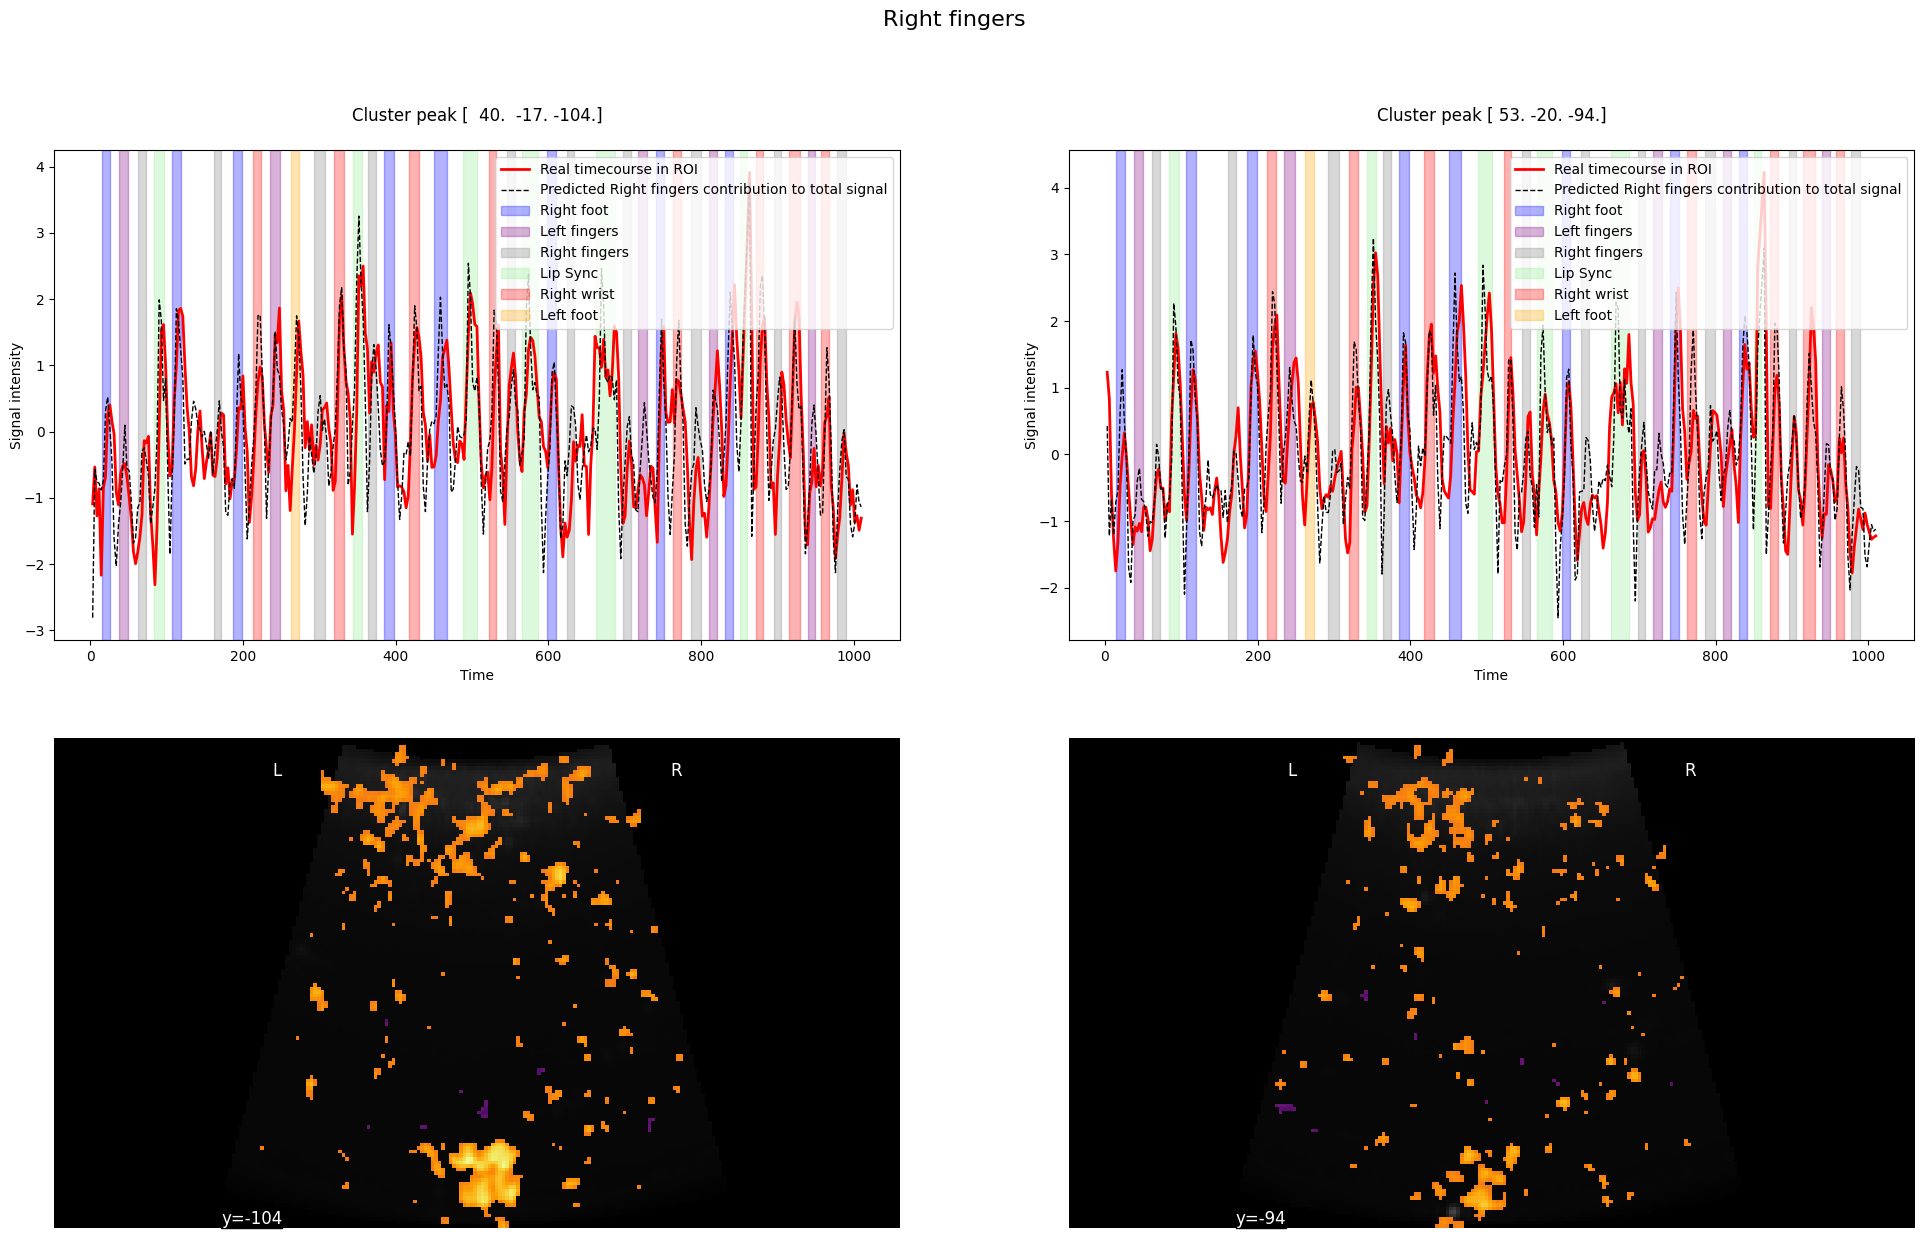

In [22]:
#######################################################################################
#  Extract time series of clusters with z-scores > 3.1 and display their time courses #
#######################################################################################
import pandas as pd
# Create probe events DataFrame with time_stamp column
probe_events = pd.DataFrame(columns=['time_stamp'])
probe_events['time_stamp'] = frame_times


contrast = "Right fingers"
threshold = 3.1
roi_radius = 10
[z_map, coords, real_timecourse, predicted_timecourse] = (
    utils.extract_time_course_from_main_clusters(
        contrast,
        threshold,
        sample_masks,
        fusi_img,
        fusi_glm,
        probe_events,
        t_r,
        roi_radius
    )
)
utils.display_real_and_predicted_timecourses(contrast,real_timecourse, predicted_timecourse,task_events, coords, z_map, mean_image)
# utils.display_predicted_timecourses(contrast, predicted_timecourse,task_events, coords, z_map, mean_image)

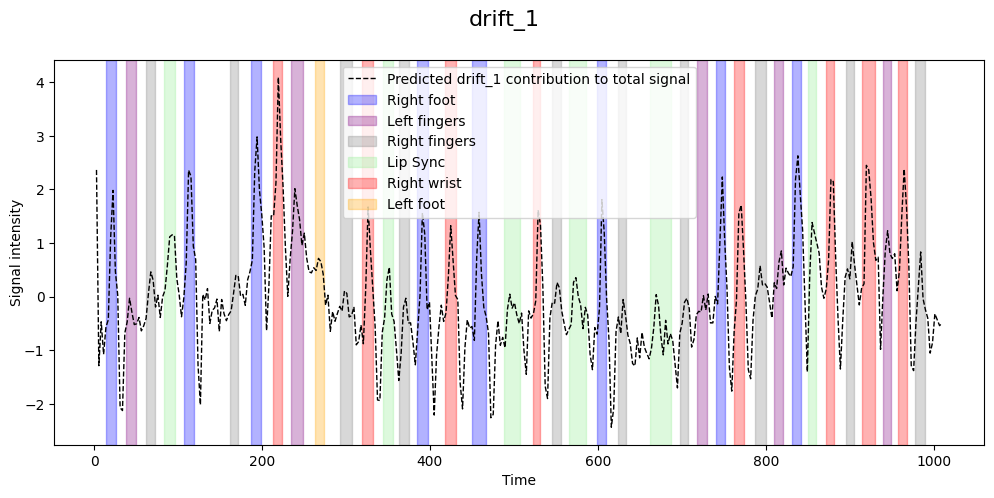

In [23]:
#######################################
#  Extract time series of regressors #
######################################
contrast = "drift_1"

utils.display_regressor_temporal_component(
    contrast,
    fusi_glm=fusi_glm,
    probe_events=probe_events,
    t_r=t_r,
    sample_masks=sample_masks,
    task_events=task_events,
)
